In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
DATA_DIR = 'Dataset'  
timestamp_columns = ["order_purchase_timestamp",
             "order_approved_at",
             "order_delivered_carrier_date", 
             "order_delivered_customer_date",
             "order_estimated_delivery_date",
             "shipping_limit_date",
             "review_creation_date",
             "review_answer_timestamp"]
df = pd.read_csv(f'../{DATA_DIR}/Cleaned Data/cleaned.csv', parse_dates=timestamp_columns)
df.head(3)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,review_creation_date,review_answer_timestamp,seller_lat,seller_lng,seller_geo_city,seller_geo_state,customer_lat,customer_lng,customer_geo_city,customer_geo_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.0,87285b34884572647811a353c7ac498a,...,2017-10-11,2017-10-12 03:43:48,-23.680729,-46.444238,maua,SP,-23.576983,-46.587161,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1.0,595fac2a385ac33a80bd5114aec74eb8,...,2018-08-08,2018-08-08 18:37:50,-19.807681,-43.980427,belo horizonte,MG,-12.177924,-44.660711,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1.0,aa4383b373c6aca5d8797843e5594415,...,2018-08-18,2018-08-22 19:07:58,-21.363502,-48.229601,guariba,SP,-16.745150,-48.514783,vianopolis,GO


# **Section 4: Exploratory Data Analysis**

## **4.1 Number of Products with Late Delivery**

This analysis shows the number of unique products that experienced late deliveries compared to those delivered on time.

In [3]:
late_delivery = (
    (df["order_status"] == "delivered") &
    (df["order_delivered_customer_date"] > df["order_estimated_delivery_date"])
)

total_late_products = df.loc[late_delivery, "product_id"].nunique()
total_products = df.loc[df["order_status"] == "delivered","product_id"].nunique()
late_product_percentage = total_late_products / total_products

print(f"Total number of products: {total_products}")
print(
    f"Total number of products that experienced late delivery: "
    f"{total_late_products} ({late_product_percentage:.1%})"
)

Total number of products: 31875
Total number of products that experienced late delivery: 5155 (16.2%)


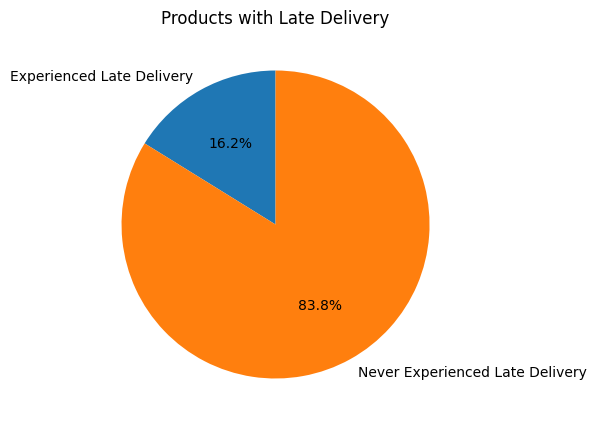

In [4]:
product_late_status = pd.Series({
    "Experienced Late Delivery": total_late_products,
    "Never Experienced Late Delivery": total_products - total_late_products
})

product_late_status.plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(5,5),
    startangle=90
)

plt.ylabel("")
plt.title("Products with Late Delivery")
plt.show()

**Insight**:
* 16.2% of unique products have experienced late delivery. Late delivery is not widespread across the entire product catalog, suggesting that certain product characteristics may be associated with a higher risk of delays.

## **4.2 Late Delivery by Product Category**

This analysis identifies which product categories have a higher proportion of products experiencing late delivery.

In [5]:
# - Group products by category and count the number of unique products.
# - Calculate the median number of products across categories.
# - Categories below the median product volume were excluded to minimize volatility from small sample sizes.
# - Rank the remaining categories based on their late-delivery rate.

product_category_summary = (
    df.groupby("product_category_name_english")["product_id"]
      .nunique()
      .rename("total_products")
      .to_frame()
)
product_category_summary["late_percentage"] = (
    df[late_delivery]
    .groupby("product_category_name_english")["product_id"]
    .nunique()
    / product_category_summary["total_products"]
    * 100
)

median_products = product_category_summary["total_products"].median()

product_category_summary_filtered = product_category_summary[
    product_category_summary["total_products"] >= median_products
].sort_values("late_percentage", ascending=False)

print(f"Median total products per category: {median_products}")
product_category_summary_filtered

Median total products per category: 95.0


,total_products,late_percentage
product_category_name_english,,
electronics,515,25.242718
office_furniture,308,23.376623
telephony,1125,21.333333
home_comfort,115,20.000000
bed_bath_table,2988,18.607764
baby,907,18.302095
computers_accessories,1625,17.723077
cool_stuff,785,17.707006
furniture_living_room,155,17.419355


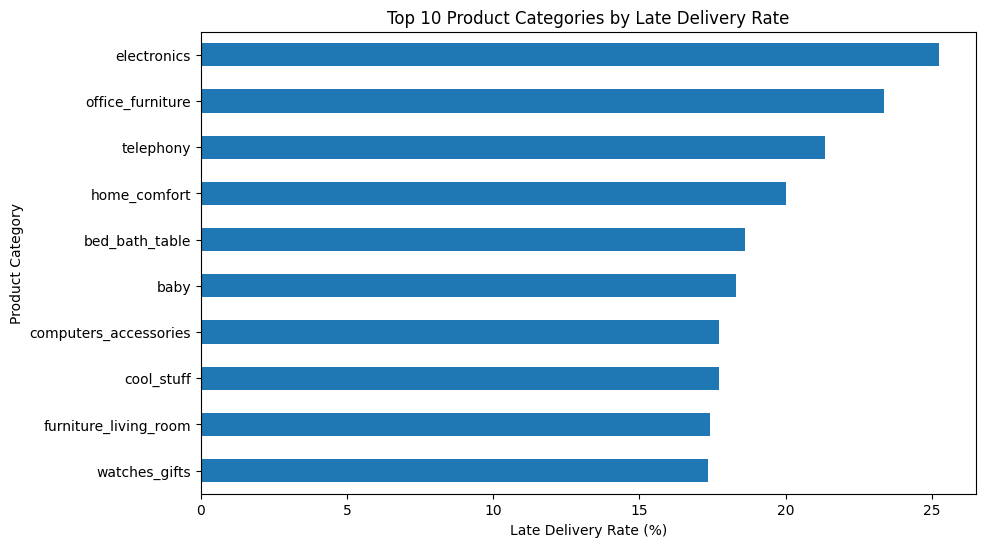

In [6]:
product_category_summary_filtered.head(10).sort_values(
    "late_percentage"
)["late_percentage"].plot(
    kind="barh",
    figsize=(10,6)
)

plt.xlabel("Late Delivery Rate (%)")
plt.ylabel("Product Category")
plt.title("Top 10 Product Categories by Late Delivery Rate")
plt.show()

**Insight**

* **16.2% of unique products experienced late delivery**, but several product categories had higher late-product rates than this overall benchmark.
* **Electronics** had the highest late-product rate at **25.2%**, followed by **office furniture (23.4%)** and **telephony (21.3%)**.
* **Bed & bath table** and **sports & leisure** had a larger number of products, but their late-product rates were lower than the top categories. This shows that **higher product volume does not necessarily mean a higher late-delivery rate**.

**Business Recommendation**
* These findings can help Olist **prioritize improvements in high-risk product categories** rather than applying the same approach across all categories. Olist can further investigate the sellers, locations, and logistics partners associated with delays in these categories.


## **4.3 Delay Days Across Product Categories**

This analysis looks at how long orders are delayed across different product categories and identify categories with longer delivery delays.

In [7]:
# - Group delayed orders by category and calculate the median delay days.
# - Calculate the median delay days across all delayed orders.
# - Rank product categories based on their median delay days.

delay_days = (df["order_delivered_customer_date"] - df["order_estimated_delivery_date"]).dt.days

late_df = df.loc[late_delivery].copy()
late_df["delay_days"] = delay_days.loc[late_df.index]

product_category_delay_summary = (
    late_df.groupby("product_category_name_english")["delay_days"]
    .median()
    .rename("median_delay_days")
    .to_frame()
    .sort_values("median_delay_days", ascending=False)
)

median_delay = late_df["delay_days"].median()

print(f"Median delay days: {median_delay:.0f} days")

product_category_delay_summary

Median delay days: 5 days


,median_delay_days
product_category_name_english,
music,14.0
air_conditioning,13.0
fashion_male_clothing,11.0
furniture_mattress_and_upholstery,9.0
fixed_telephony,9.0
...,...
construction_tools_lights,2.0
home_construction,2.0
food,1.0


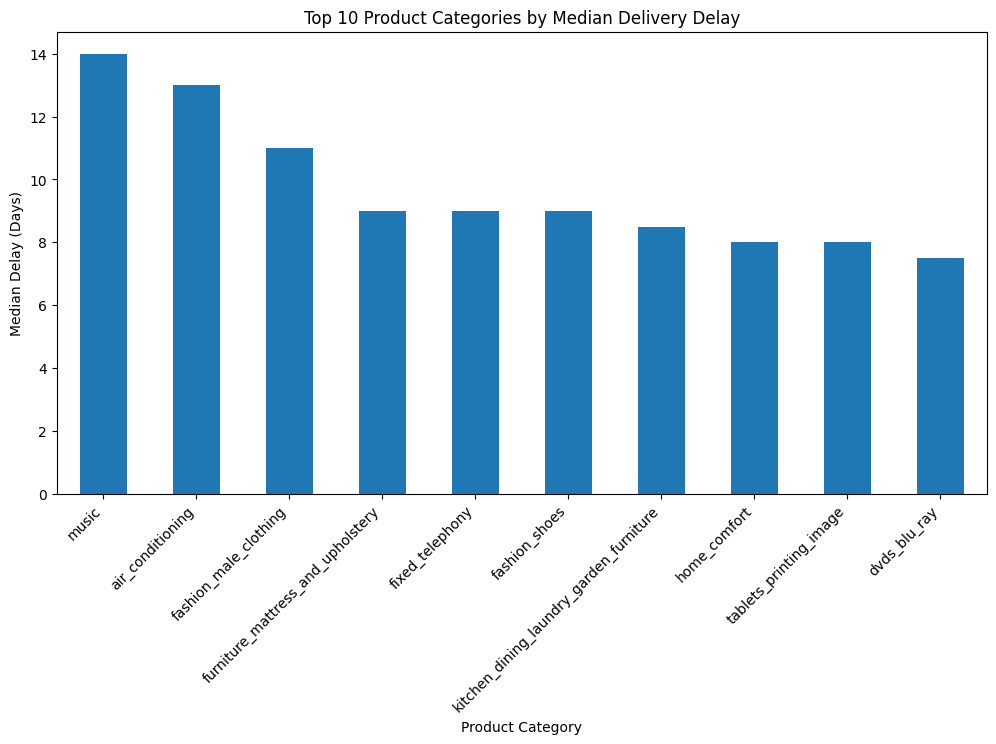

In [8]:
# Distribution of Top 10 Product Categories by Median Delivery Delay
late_df.groupby(
    "product_category_name_english"
)["delay_days"].median().sort_values(ascending=False).head(10).plot(
    kind="bar",
    figsize=(12, 6)
)

plt.xlabel("Product Category")
plt.ylabel("Median Delay (Days)")
plt.title("Top 10 Product Categories by Median Delivery Delay")
plt.xticks(rotation=45, ha="right")
plt.show()

In [10]:
product_category_comparison = (
    product_category_summary_filtered
    .join(product_category_delay_summary)
    .head(10)
    .reset_index()
)

product_category_comparison

,product_category_name_english,total_products,late_percentage,median_delay_days
0,electronics,515,25.242718,4.0
1,office_furniture,308,23.376623,5.0
2,telephony,1125,21.333333,4.0
3,home_comfort,115,20.000000,8.0
4,bed_bath_table,2988,18.607764,6.0
5,baby,907,18.302095,6.0
6,computers_accessories,1625,17.723077,5.0
7,cool_stuff,785,17.707006,5.0
8,furniture_living_room,155,17.419355,6.0
9,watches_gifts,1319,17.361638,5.0


**Insight**:
* Music has the longest average delay at 14 days, followed by air conditioning (13 days) and fashion male clothing (11 days).
* The top 10 product categories experienced delays of more than the median delay days (5 days)
* Some categories have relatively short delays, such as food (1 day) and home construction (2 days)
* In comparison, the top 10 categories with the highest late-delivery rates have median delays of 4–6 days, indicating that these categories are more frequently delayed but do not necessarily experience the most severe delays.


## **4.4 Late Delivery by Product Characteristic**

This analysis explores whether product characteristics, such as weight, length, height and width are associated with late delivery.

In [ ]:
# Define Product Characteristics:
product_characteristic = [
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm"
]

# Product Characteristics: Late vs On-time
# -Compare the median weight and dimensions of products between late and on-time deliveries.

df.groupby(late_delivery)[product_characteristic].median()

,product_weight_g,product_length_cm,product_height_cm,product_width_cm
False,700.0,25.0,13.0,20.0
True,757.0,25.0,13.0,20.0


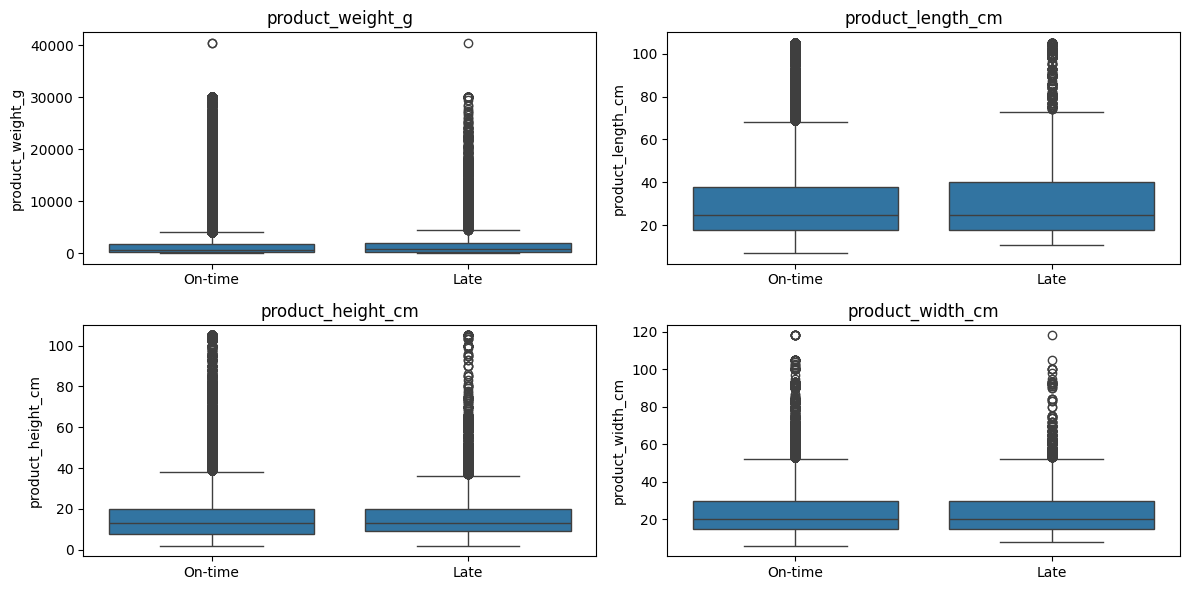

In [ ]:
# Distribution of Product Characteristics

fig, axes = plt.subplots(2, 2, figsize=(12, 6))

for i, col in enumerate(product_characteristic):
    sns.boxplot(
        x=late_delivery,
        y=df[col],
        ax=axes.flat[i]
    )
    
    axes.flat[i].set_xticks([0, 1])
    axes.flat[i].set_xticklabels(["On-time", "Late"])
    axes.flat[i].set_xlabel("")
    axes.flat[i].set_ylabel(col)
    axes.flat[i].set_title(col)

plt.tight_layout()
plt.show()

In [ ]:
# Statistical Test
# Use the Mann–Whitney U test to check whether product characteristics significantly difference between late and on-time deliveries.

from scipy.stats import mannwhitneyu

# H0 = There is a significant product characteristic difference between late and on-time deliveries
# H1 = There is no significant product characteristic difference between late and on-time deliveries

for col in product_characteristic:
    on_time = df.loc[~late_delivery, col].dropna()
    late = df.loc[late_delivery, col].dropna()

    stat, p_value = mannwhitneyu(
        on_time,
        late,
        alternative="two-sided"
    )

    print(f"{col}")
    print(f"p-value: {p_value:.4f}")
    print(f"p-value: {p_value:.4f}")

    if p_value < 0.05:
        print(f"Reject H0 → There is a significant {col} difference between late and on-time deliveries.")
    else:
        print(f"Fail to reject H0 → There is no significant {col} difference between late and on-time deliveries.")
    print()

product_weight_g
p-value: 0.0000
p-value: 0.0000
Reject H0 → There is a significant product_weight_g difference between late and on-time deliveries.

product_length_cm
p-value: 0.0014
p-value: 0.0014
Reject H0 → There is a significant product_length_cm difference between late and on-time deliveries.

product_height_cm
p-value: 0.0159
p-value: 0.0159
Reject H0 → There is a significant product_height_cm difference between late and on-time deliveries.

product_width_cm
p-value: 0.4458
p-value: 0.4458
Fail to reject H0 → There is no significant product_width_cm difference between late and on-time deliveries.



**Insight:**
* Product weight shows a statistically significant difference between late and on-time orders, but the difference in median weight is relatively small (700g vs 757g).
* Some product dimensions also show statistically significant differences despite having the same median values, suggesting that the differences are mainly found in the overall distributions, rather than at the median level.
* Product characteristics show some differences between late and on-time deliveries, but the differences are relatively small. This suggest that product characteristics alone are unlikely to be a major driver of delivery delays.

**Business Recommendation:**
- Although product characteristic is not the major driver of delivery delays, Olist still can monitor heavier and larger products as potential risk factors for delivery delays, especially when combined with other delivery-related factors.